# Supertargeting Demo

This notebook demonstrates a minimal workflow for reading heat-integration stream data from Excel and running automatic supertargeting calculations.

## What This Demo Covers

1. Read the local Excel stream sheet
2. Convert rows into `ThermalStream` objects
3. Run supertargeting for a selected $\Delta T_{\min}$
4. Inspect the stream table, summary metrics, area intervals, composite curve, and balanced composite curve

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import Image, display

PROCESS_ONLY_UTILITY_NAMES = {'Hot Oil', 'HP Steam', 'Cooling Water', 'Refrigerant 2', 'Fired Heat (1000)'}

NOTEBOOK_DIR = Path.cwd().resolve()
SUPER_RIGHT_DIR = NOTEBOOK_DIR.parent
ROOT = SUPER_RIGHT_DIR.parent
SUPERTARGETING_ROOT = ROOT / '06_HYSYS_Supertargeting'

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(SUPERTARGETING_ROOT) not in sys.path:
    sys.path.insert(0, str(SUPERTARGETING_ROOT))

from tex_tables.generate_supertargeting_area_target import parse_xlsx_rows, stream_rows_from_workbook
from hysys_utils.supertargeting import _rows_to_streams, curve_plot_records, run_supertargeting


In [2]:
INPUT_XLSX = NOTEBOOK_DIR / 'Input Sheet of 20.xlsx'
IMAGE_DIR = NOTEBOOK_DIR / 'images'
DELTA_TMIN_C = 20.0

INPUT_XLSX

PosixPath('/scratch/projects/CFP04/CFP04-CF-050/ces/super_right/github/Input Sheet of 20.xlsx')

In [3]:
workbook_rows = parse_xlsx_rows(INPUT_XLSX)
stream_rows = stream_rows_from_workbook(workbook_rows)

streams_df = pd.DataFrame(
    stream_rows,
    columns=['Stream Information', 'Supply Temperature (C)', 'Target Temperature (C)', 'Heat Load (kW)', 'U (kW/m2-K)', 'CP (kW/K)'],
)
streams_df.index = streams_df.index + 1
streams_df

,Stream Information,Supply Temperature (C),Target Temperature (C),Heat Load (kW),U (kW/m2-K),CP (kW/K)
1,Condenser@COL1,35.9,-21.1,8.975000,0.213889,0.157456
2,Condenser@COL2,86.1,85.6,2702.500000,0.189861,5405.000000
3,Condenser@COL3,157.8,137.5,94.416667,0.699639,4.651067
4,Cooler1,666.6,328.1,13630.555556,0.313556,40.267520
5,Cooler2,328.1,37.8,10469.444444,0.608861,36.064225
6,Cooler3,83.6,30.0,299.166667,0.924889,5.581468
7,Cooler4,260.0,30.0,232.611111,1.135000,1.011353
8,Heater1,50.8,239.7,6875.000000,0.155028,36.394918
9,Heater2,239.7,648.0,15277.777778,0.071028,37.418021
10,Reboiler@COL1,180.8,182.7,1071.666667,2.418667,564.035088


In [4]:
streams = _rows_to_streams(workbook_rows)
result = run_supertargeting(streams, delta_tmin_c=DELTA_TMIN_C)

summary_df = pd.DataFrame(
    [
        {'Metric': 'Delta Tmin (C)', 'Value': DELTA_TMIN_C},
        {'Metric': 'Pinch hot temperature (C)', 'Value': result.pinch_hot_c},
        {'Metric': 'Pinch cold temperature (C)', 'Value': result.pinch_cold_c},
        {'Metric': 'Minimum hot utility (kW)', 'Value': result.minimum_hot_utility_kw},
        {'Metric': 'Minimum cold utility (kW)', 'Value': result.minimum_cold_utility_kw},
        {'Metric': 'Minimum area (m2)', 'Value': result.minimum_area_m2},
    ]
)
summary_df

,Metric,Value
0,Delta Tmin (C),20.000000
1,Pinch hot temperature (C),40.000000
2,Pinch cold temperature (C),20.000000
3,Minimum hot utility (kW),145.269498
4,Minimum cold utility (kW),145.269498
5,Minimum area (m2),2661.613694


## Total Results Table

This consolidated table summarizes the current `\Delta T_{\min}=20^\circ C` case for both all-stream and process-only views.

In [5]:
process_streams = [stream for stream in streams if stream.name not in PROCESS_ONLY_UTILITY_NAMES]
assert not any(stream.name in PROCESS_ONLY_UTILITY_NAMES for stream in process_streams)
process_result = run_supertargeting(process_streams, delta_tmin_c=DELTA_TMIN_C)

total_results_df = pd.DataFrame(
    [
        {'Basis': 'All streams', 'Metric': 'Stream count', 'Value': len(streams)},
        {'Basis': 'All streams', 'Metric': 'Pinch hot temperature (C)', 'Value': result.pinch_hot_c},
        {'Basis': 'All streams', 'Metric': 'Pinch cold temperature (C)', 'Value': result.pinch_cold_c},
        {'Basis': 'All streams', 'Metric': 'Minimum hot utility (kW)', 'Value': result.minimum_hot_utility_kw},
        {'Basis': 'All streams', 'Metric': 'Minimum cold utility (kW)', 'Value': result.minimum_cold_utility_kw},
        {'Basis': 'All streams', 'Metric': 'Minimum area (m2)', 'Value': result.minimum_area_m2},
        {'Basis': 'Process only', 'Metric': 'Stream count', 'Value': len(process_streams)},
        {'Basis': 'Process only', 'Metric': 'Pinch hot temperature (C)', 'Value': process_result.pinch_hot_c},
        {'Basis': 'Process only', 'Metric': 'Pinch cold temperature (C)', 'Value': process_result.pinch_cold_c},
        {'Basis': 'Process only', 'Metric': 'Minimum hot utility (kW)', 'Value': process_result.minimum_hot_utility_kw},
        {'Basis': 'Process only', 'Metric': 'Minimum cold utility (kW)', 'Value': process_result.minimum_cold_utility_kw},
        {'Basis': 'Process only', 'Metric': 'Minimum area (m2)', 'Value': process_result.minimum_area_m2},
    ]
)
total_results_df

,Basis,Metric,Value
0,All streams,Stream count,17.000000
1,All streams,Pinch hot temperature (C),40.000000
2,All streams,Pinch cold temperature (C),20.000000
3,All streams,Minimum hot utility (kW),145.269498
4,All streams,Minimum cold utility (kW),145.269498
5,All streams,Minimum area (m2),2661.613694
6,Process only,Stream count,12.000000
7,Process only,Pinch hot temperature (C),168.200000
8,Process only,Pinch cold temperature (C),148.200000
9,Process only,Minimum hot utility (kW),2447.539948


In [6]:
intervals_df = pd.DataFrame(
    [
        {
            'Delta H Interval (kW)': f'{interval.enthalpy_start_kw:.1f}--{interval.enthalpy_end_kw:.1f}',
            'Th_out (C)': interval.hot_out_c,
            'Th_in (C)': interval.hot_in_c,
            'Tc_in (C)': interval.cold_in_c,
            'Tc_out (C)': interval.cold_out_c,
            'Hot Streams': list(interval.hot_stream_ids),
            'Cold Streams': list(interval.cold_stream_ids),
            'LMTD (C)': interval.lmtd_c,
            'Area (m2)': interval.area_m2,
        }
        for interval in result.area_intervals
    ]
)
intervals_df

,Delta H Interval (kW),Th_out (C),Th_in (C),Tc_in (C),Tc_out (C),Hot Streams,Cold Streams,LMTD (C),Area (m2)
0,0.0--8.0,-21.100000,30.000000,-40.000000,-40.000000,[0],[],39.027495,0.963877
1,8.0--47.9,30.000000,35.900000,-40.000000,-40.000000,"[0, 5, 6]",[],72.910218,0.620017
2,47.9--60.4,35.900000,37.800000,-40.000000,-40.000000,"[5, 6]",[],76.846085,0.171239
3,60.4--145.3,37.800000,39.789601,-40.000000,-40.000000,"[4, 5, 6]",[],78.790614,1.670607
4,145.3--154.2,39.789601,40.000000,-40.000000,20.000000,"[4, 5, 6]",[15],43.211166,1.293199
5,154.2--2014.1,40.000000,83.600000,20.000000,22.088444,"[4, 5, 6]",[14],36.948663,216.738530
6,2014.1--2088.2,83.600000,85.600000,22.088444,22.171709,"[4, 6]",[14],62.465022,5.195327
7,2088.2--4809.3,85.600000,86.100000,22.171709,25.227194,"[1, 4, 6]",[14],62.141791,350.172693
8,4809.3--6715.0,86.100000,137.500000,25.227194,27.367110,"[4, 6]",[],83.083126,37.195749
9,6715.0--7562.0,137.500000,157.800000,27.367110,28.318273,"[2, 4, 6]",[],119.546452,11.338305


In [7]:
records_bcc = pd.DataFrame(curve_plot_records(streams, result))
records_cc = pd.DataFrame(curve_plot_records(process_streams, process_result))

pd.concat(
    [
        records_cc.assign(source='process_only_cc'),
        records_bcc.assign(source='all_streams_bcc'),
    ],
    ignore_index=True,
).head()

,plot_name,curve_name,point_index,enthalpy_kw,temperature_c,cold_curve_shift_kw,source
0,composite_curve,hot_curve,1,0.000000,-21.1,0.0,process_only_cc
1,composite_curve,hot_curve,2,8.046009,30.0,0.0,process_only_cc
2,composite_curve,hot_curve,3,47.872640,35.9,0.0,process_only_cc
3,composite_curve,hot_curve,4,60.398998,37.8,0.0,process_only_cc
4,composite_curve,hot_curve,5,2014.091663,83.6,0.0,process_only_cc


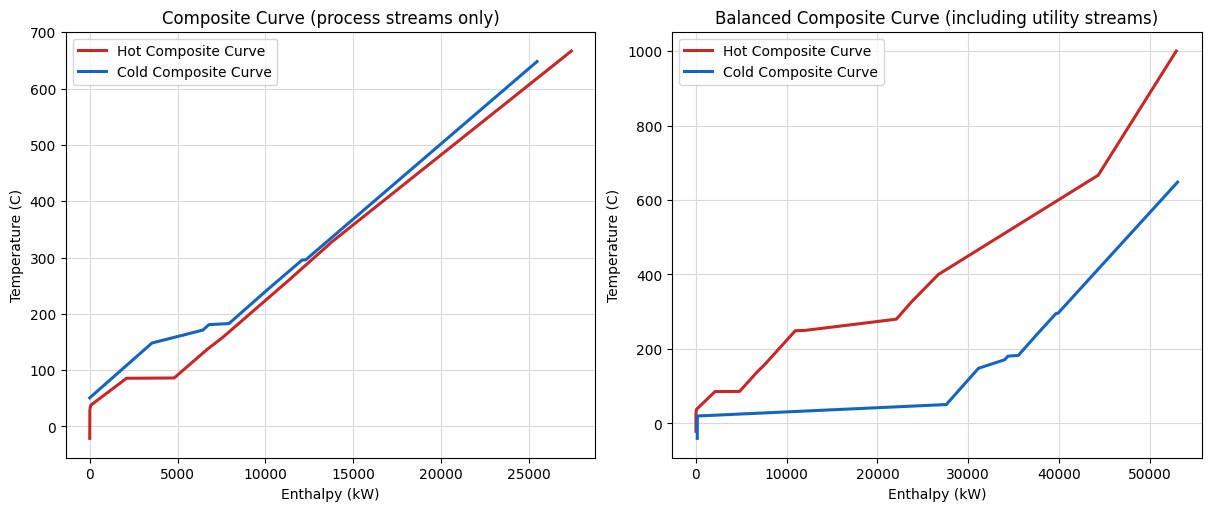

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

plot_specs = [
    (records_cc, 'composite_curve', 'Composite Curve (process streams only)'),
    (records_bcc, 'bcc_curve', 'Balanced Composite Curve (including utility streams)'),
]

for ax, (records_plot, plot_name, title) in zip(axes, plot_specs):
    hot_rows = records_plot[(records_plot['plot_name'] == plot_name) & (records_plot['curve_name'] == 'hot_curve')]
    cold_rows = records_plot[(records_plot['plot_name'] == plot_name) & (records_plot['curve_name'] == 'cold_curve')]
    ax.plot(hot_rows['enthalpy_kw'], hot_rows['temperature_c'], color='#c62828', linewidth=2.2, label='Hot Composite Curve')
    ax.plot(cold_rows['enthalpy_kw'], cold_rows['temperature_c'], color='#1565c0', linewidth=2.2, label='Cold Composite Curve')
    ax.set_title(title)
    ax.set_xlabel('Enthalpy (kW)')
    ax.set_ylabel('Temperature (C)')
    ax.grid(True, color='#d9d9d9', linewidth=0.8)
    ax.legend(frameon=True)

plt.show()


## Rendered Figures

The notebook also shows the pre-rendered figures copied into this `github` demo folder.

In [9]:
figure_map = {
    'Balanced composite curve': IMAGE_DIR / 'bcc_all_streams_dtmin20.png',
    'Partitioned BCC': IMAGE_DIR / 'bcc_all_streams_partitioned_dtmin20.png',
    'Composite curve without utility streams': IMAGE_DIR / 'composite_curve_process_only_dtmin20.png',
    'ACC / TOC / TAC vs Delta Tmin': IMAGE_DIR / 'dtmin_economics_aligned_bcc.png',
}

pd.DataFrame({'Figure': list(figure_map.keys()), 'Path': [str(path) for path in figure_map.values()]})

,Figure,Path
0,Balanced composite curve,/scratch/projects/CFP04/CFP04-CF-050/ces/super...
1,Partitioned BCC,/scratch/projects/CFP04/CFP04-CF-050/ces/super...
2,Composite curve without utility streams,/scratch/projects/CFP04/CFP04-CF-050/ces/super...
3,ACC / TOC / TAC vs Delta Tmin,/scratch/projects/CFP04/CFP04-CF-050/ces/super...


Balanced composite curve


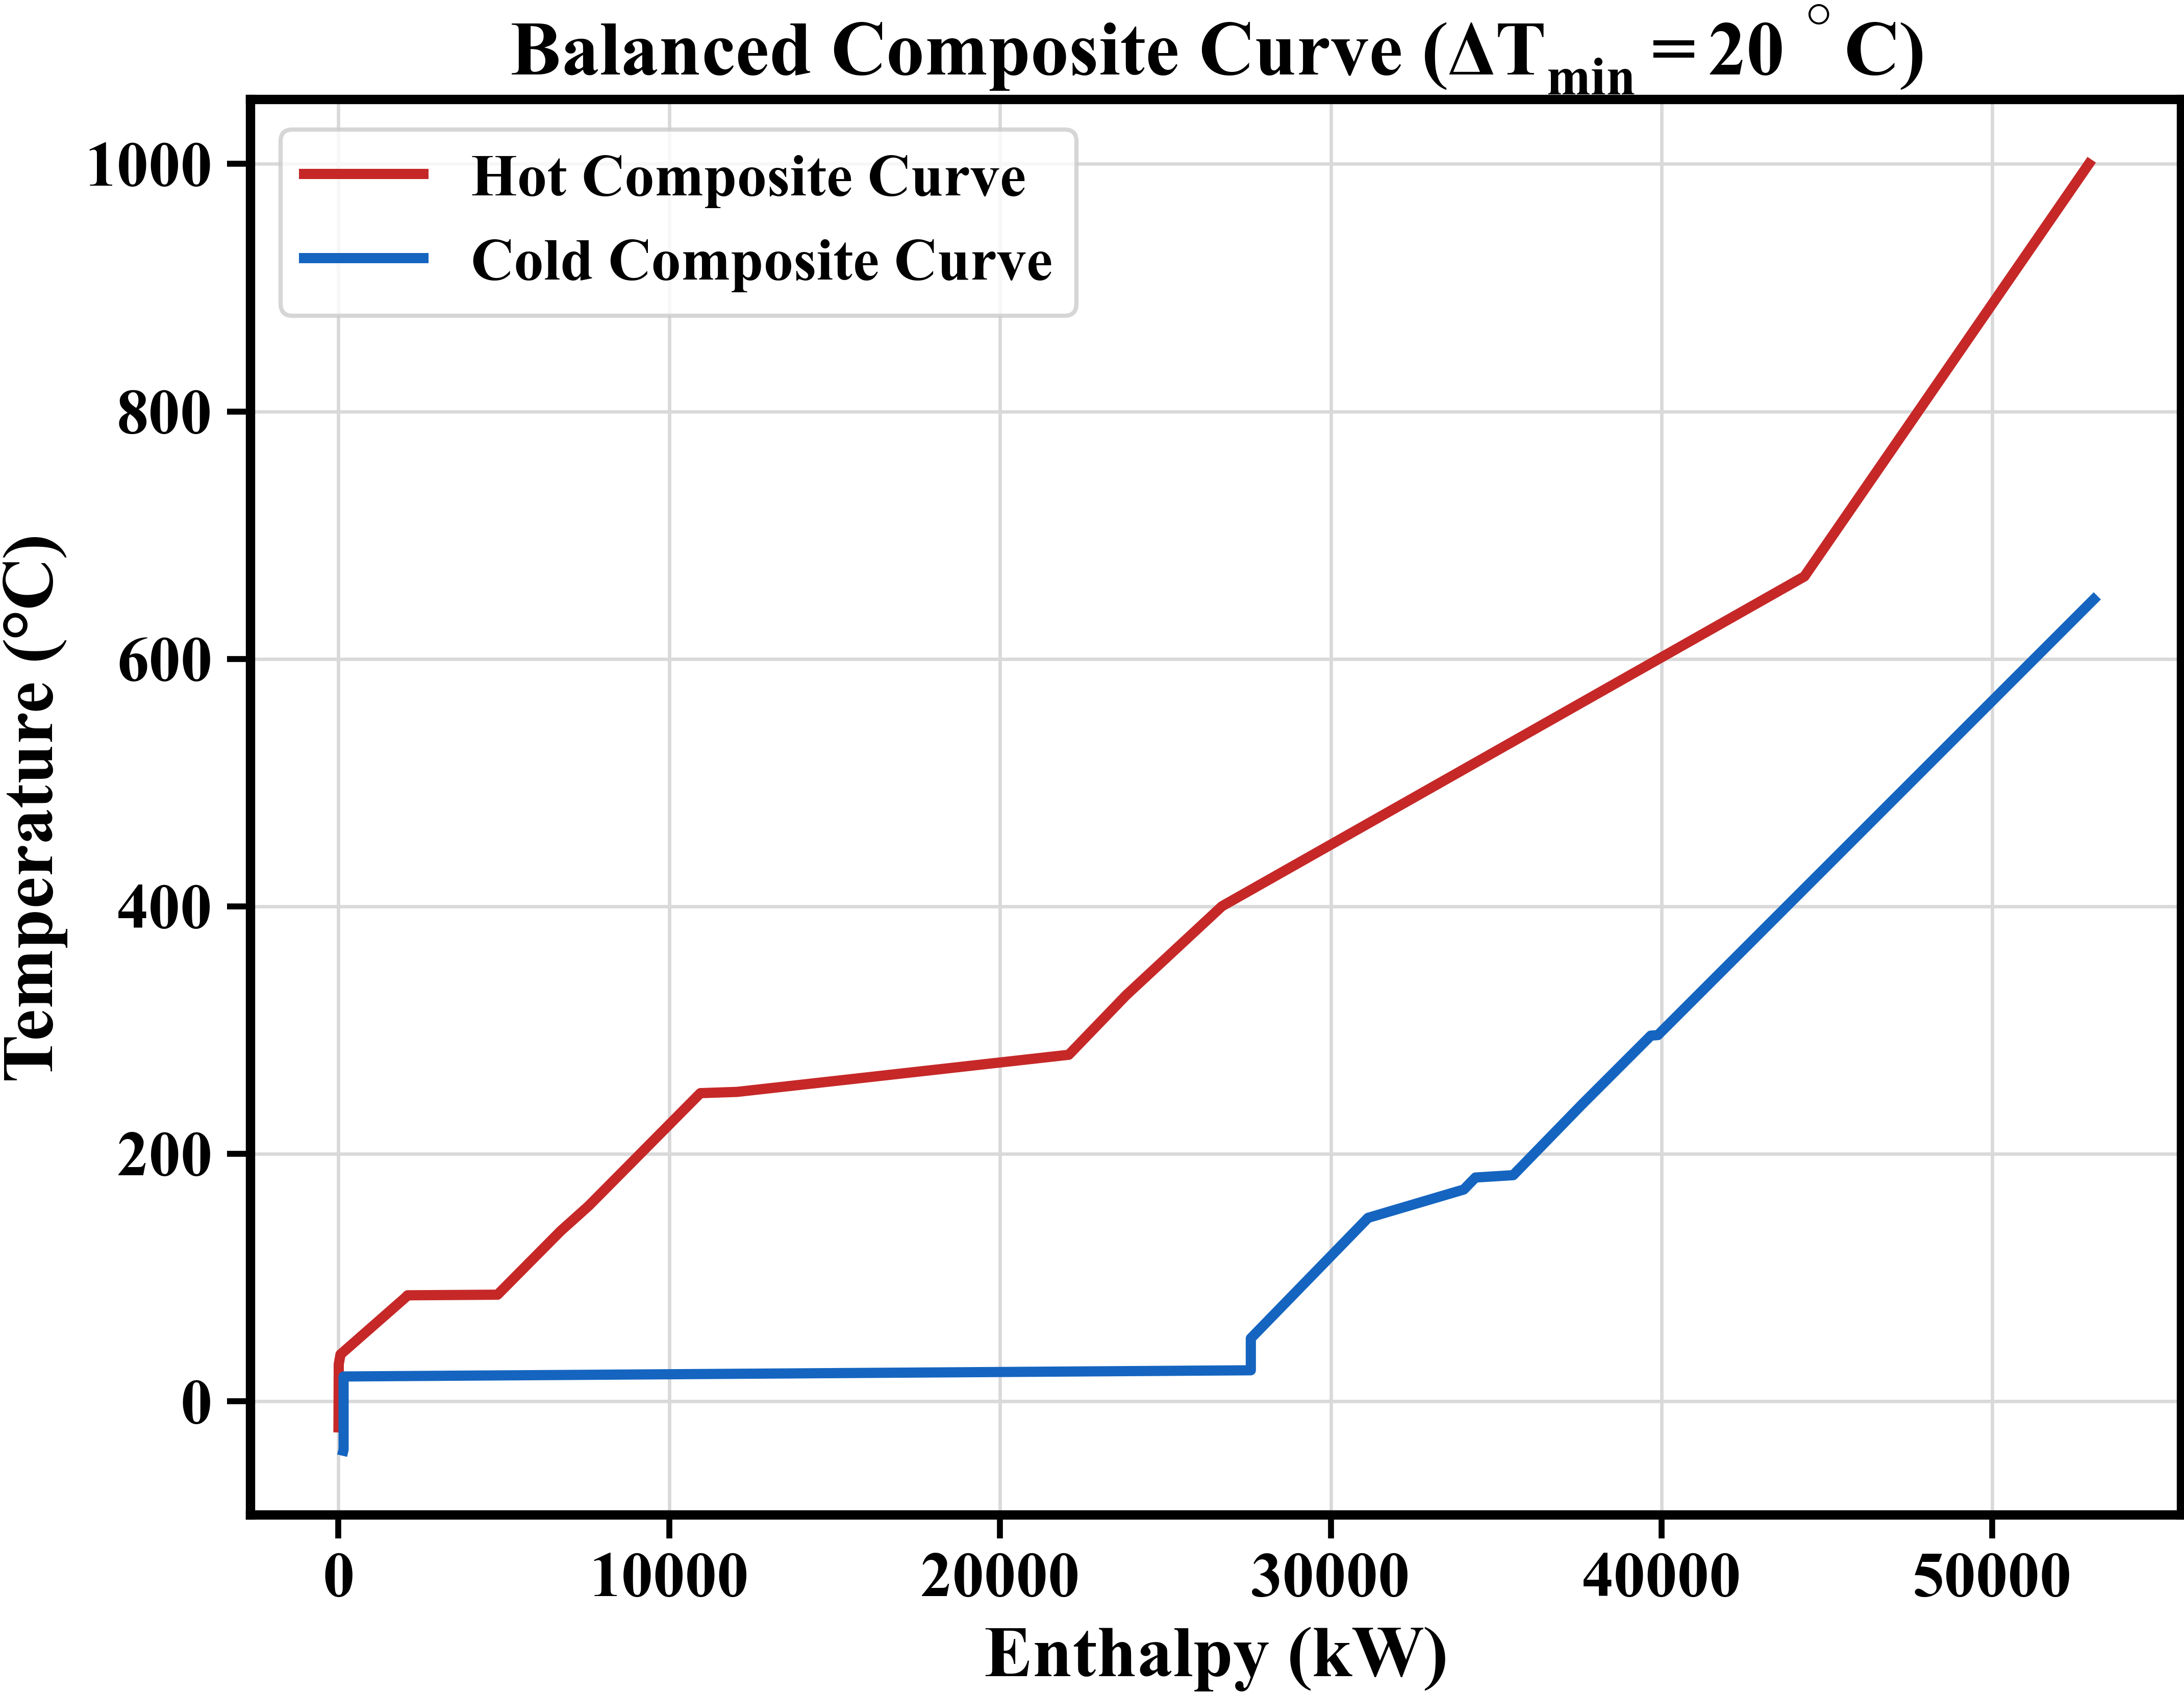

Partitioned BCC


Composite curve without utility streams


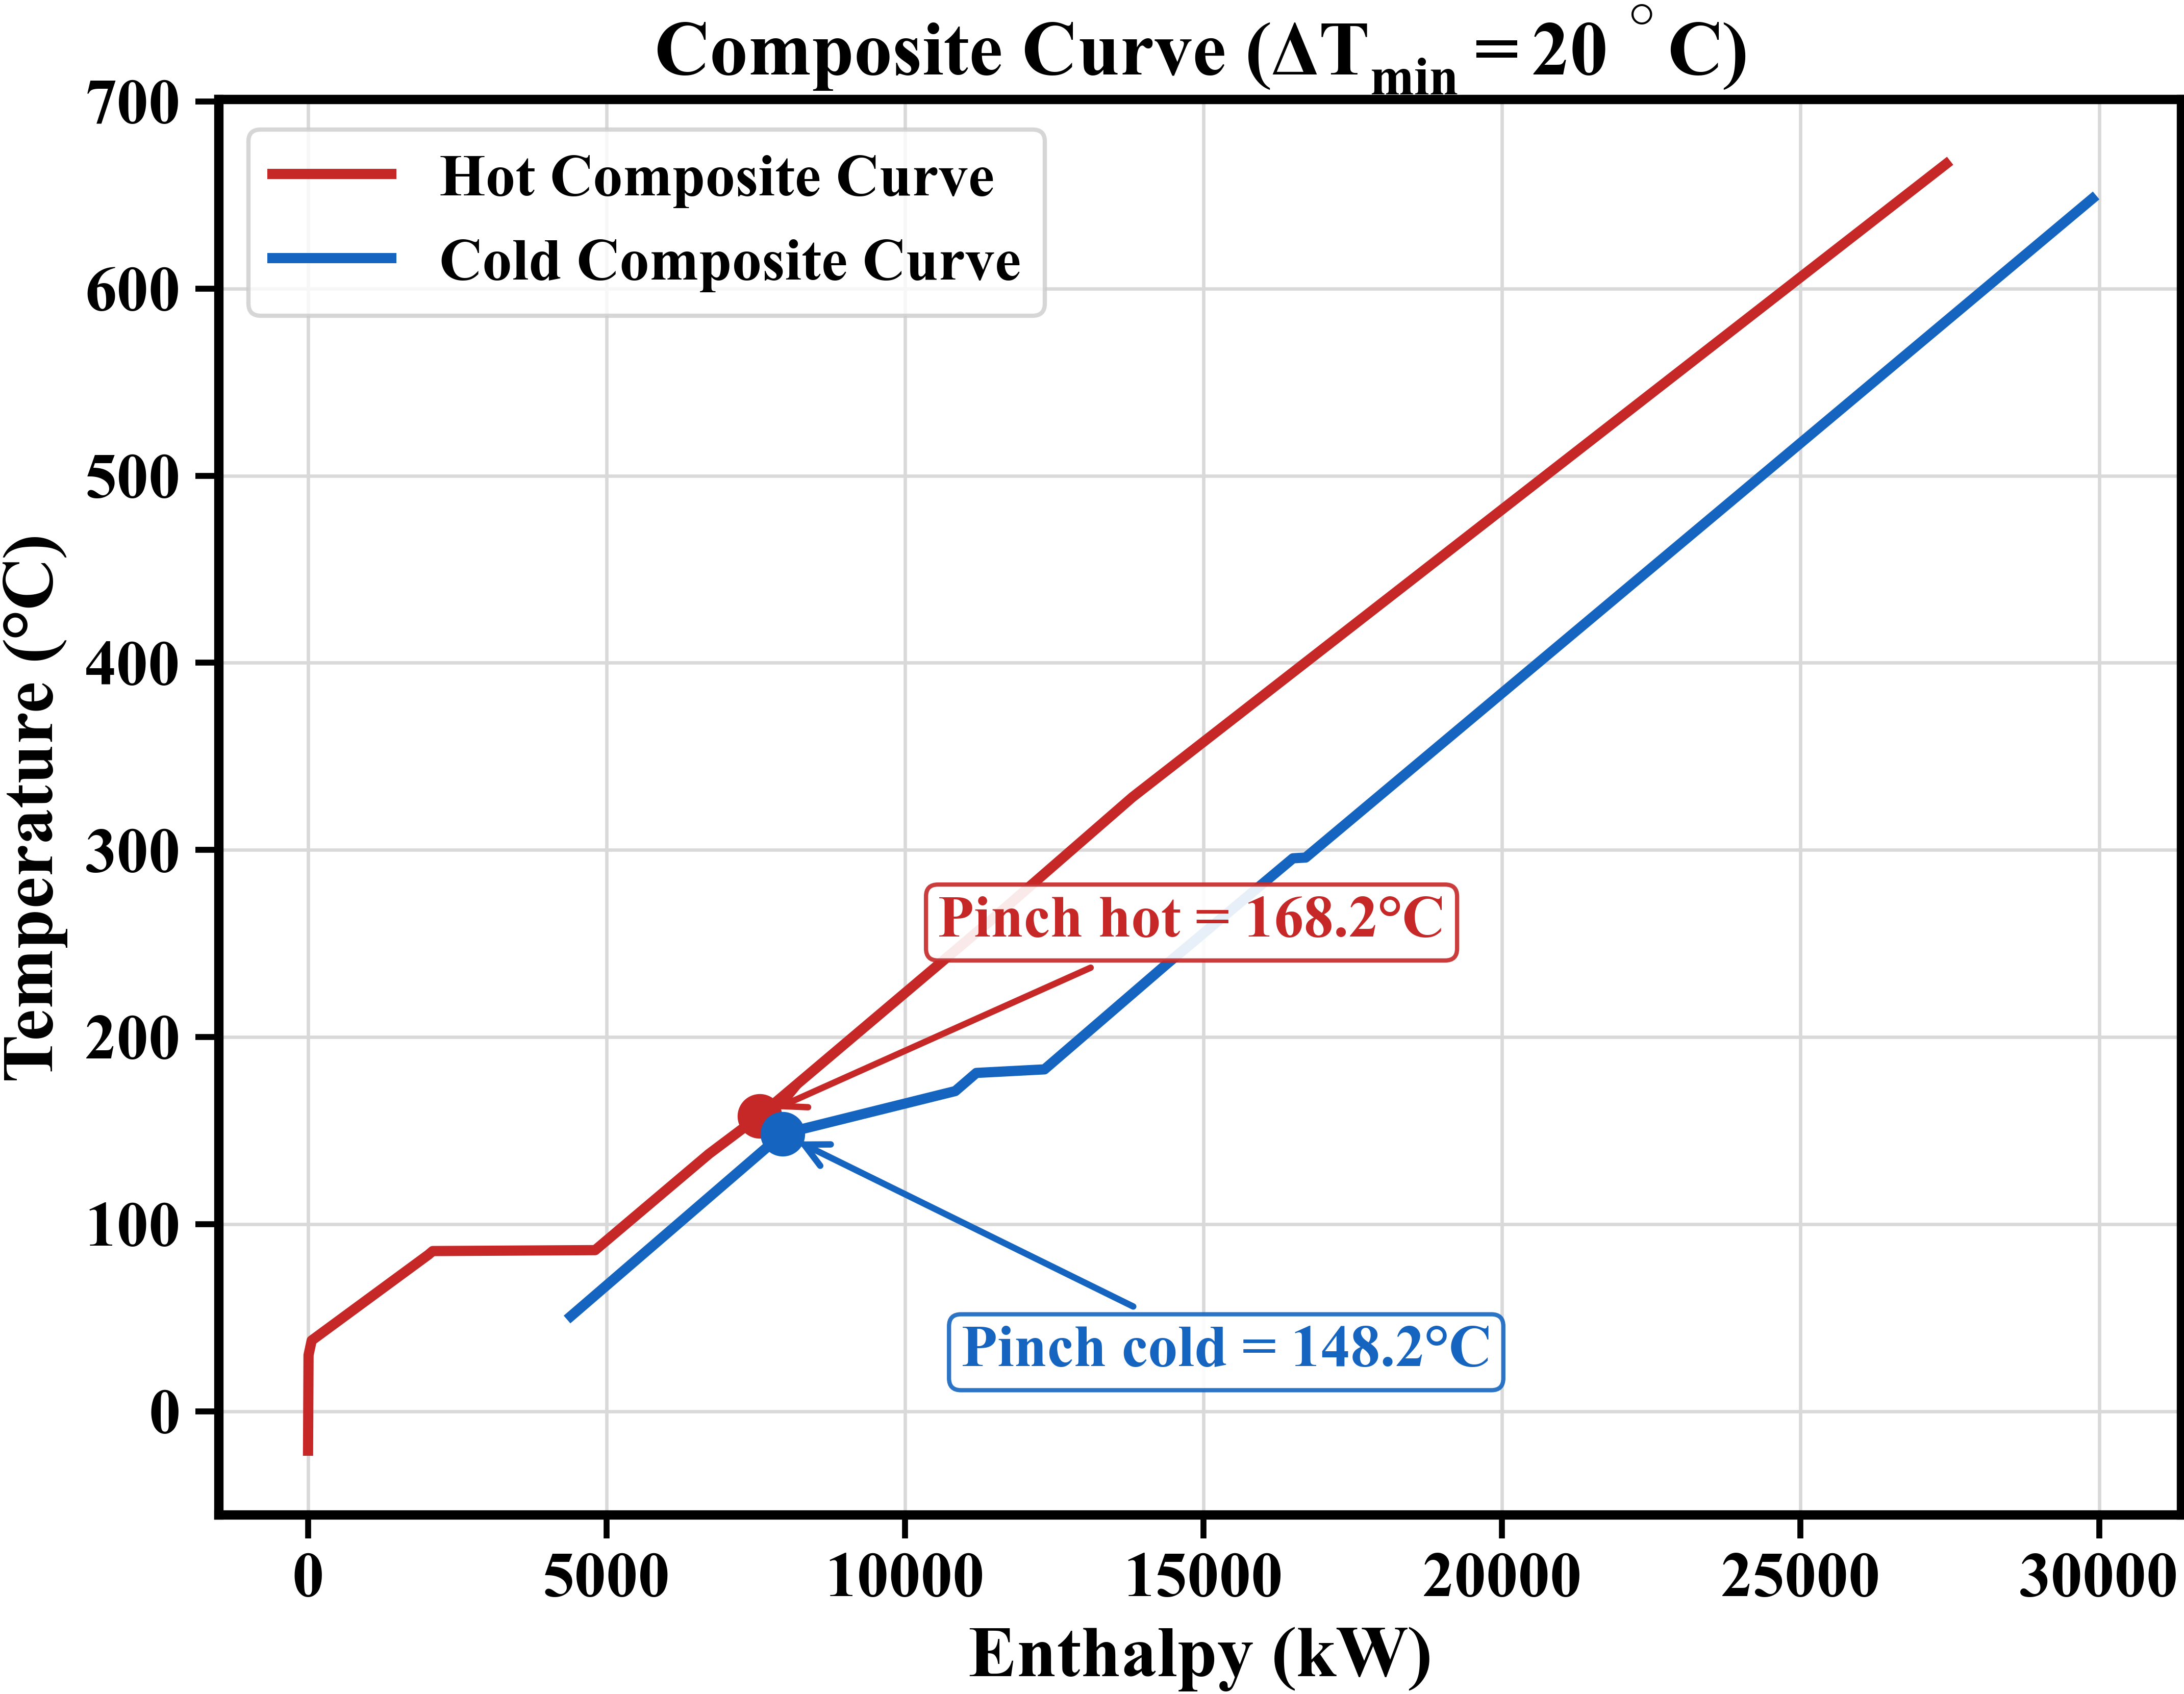

ACC / TOC / TAC vs Delta Tmin


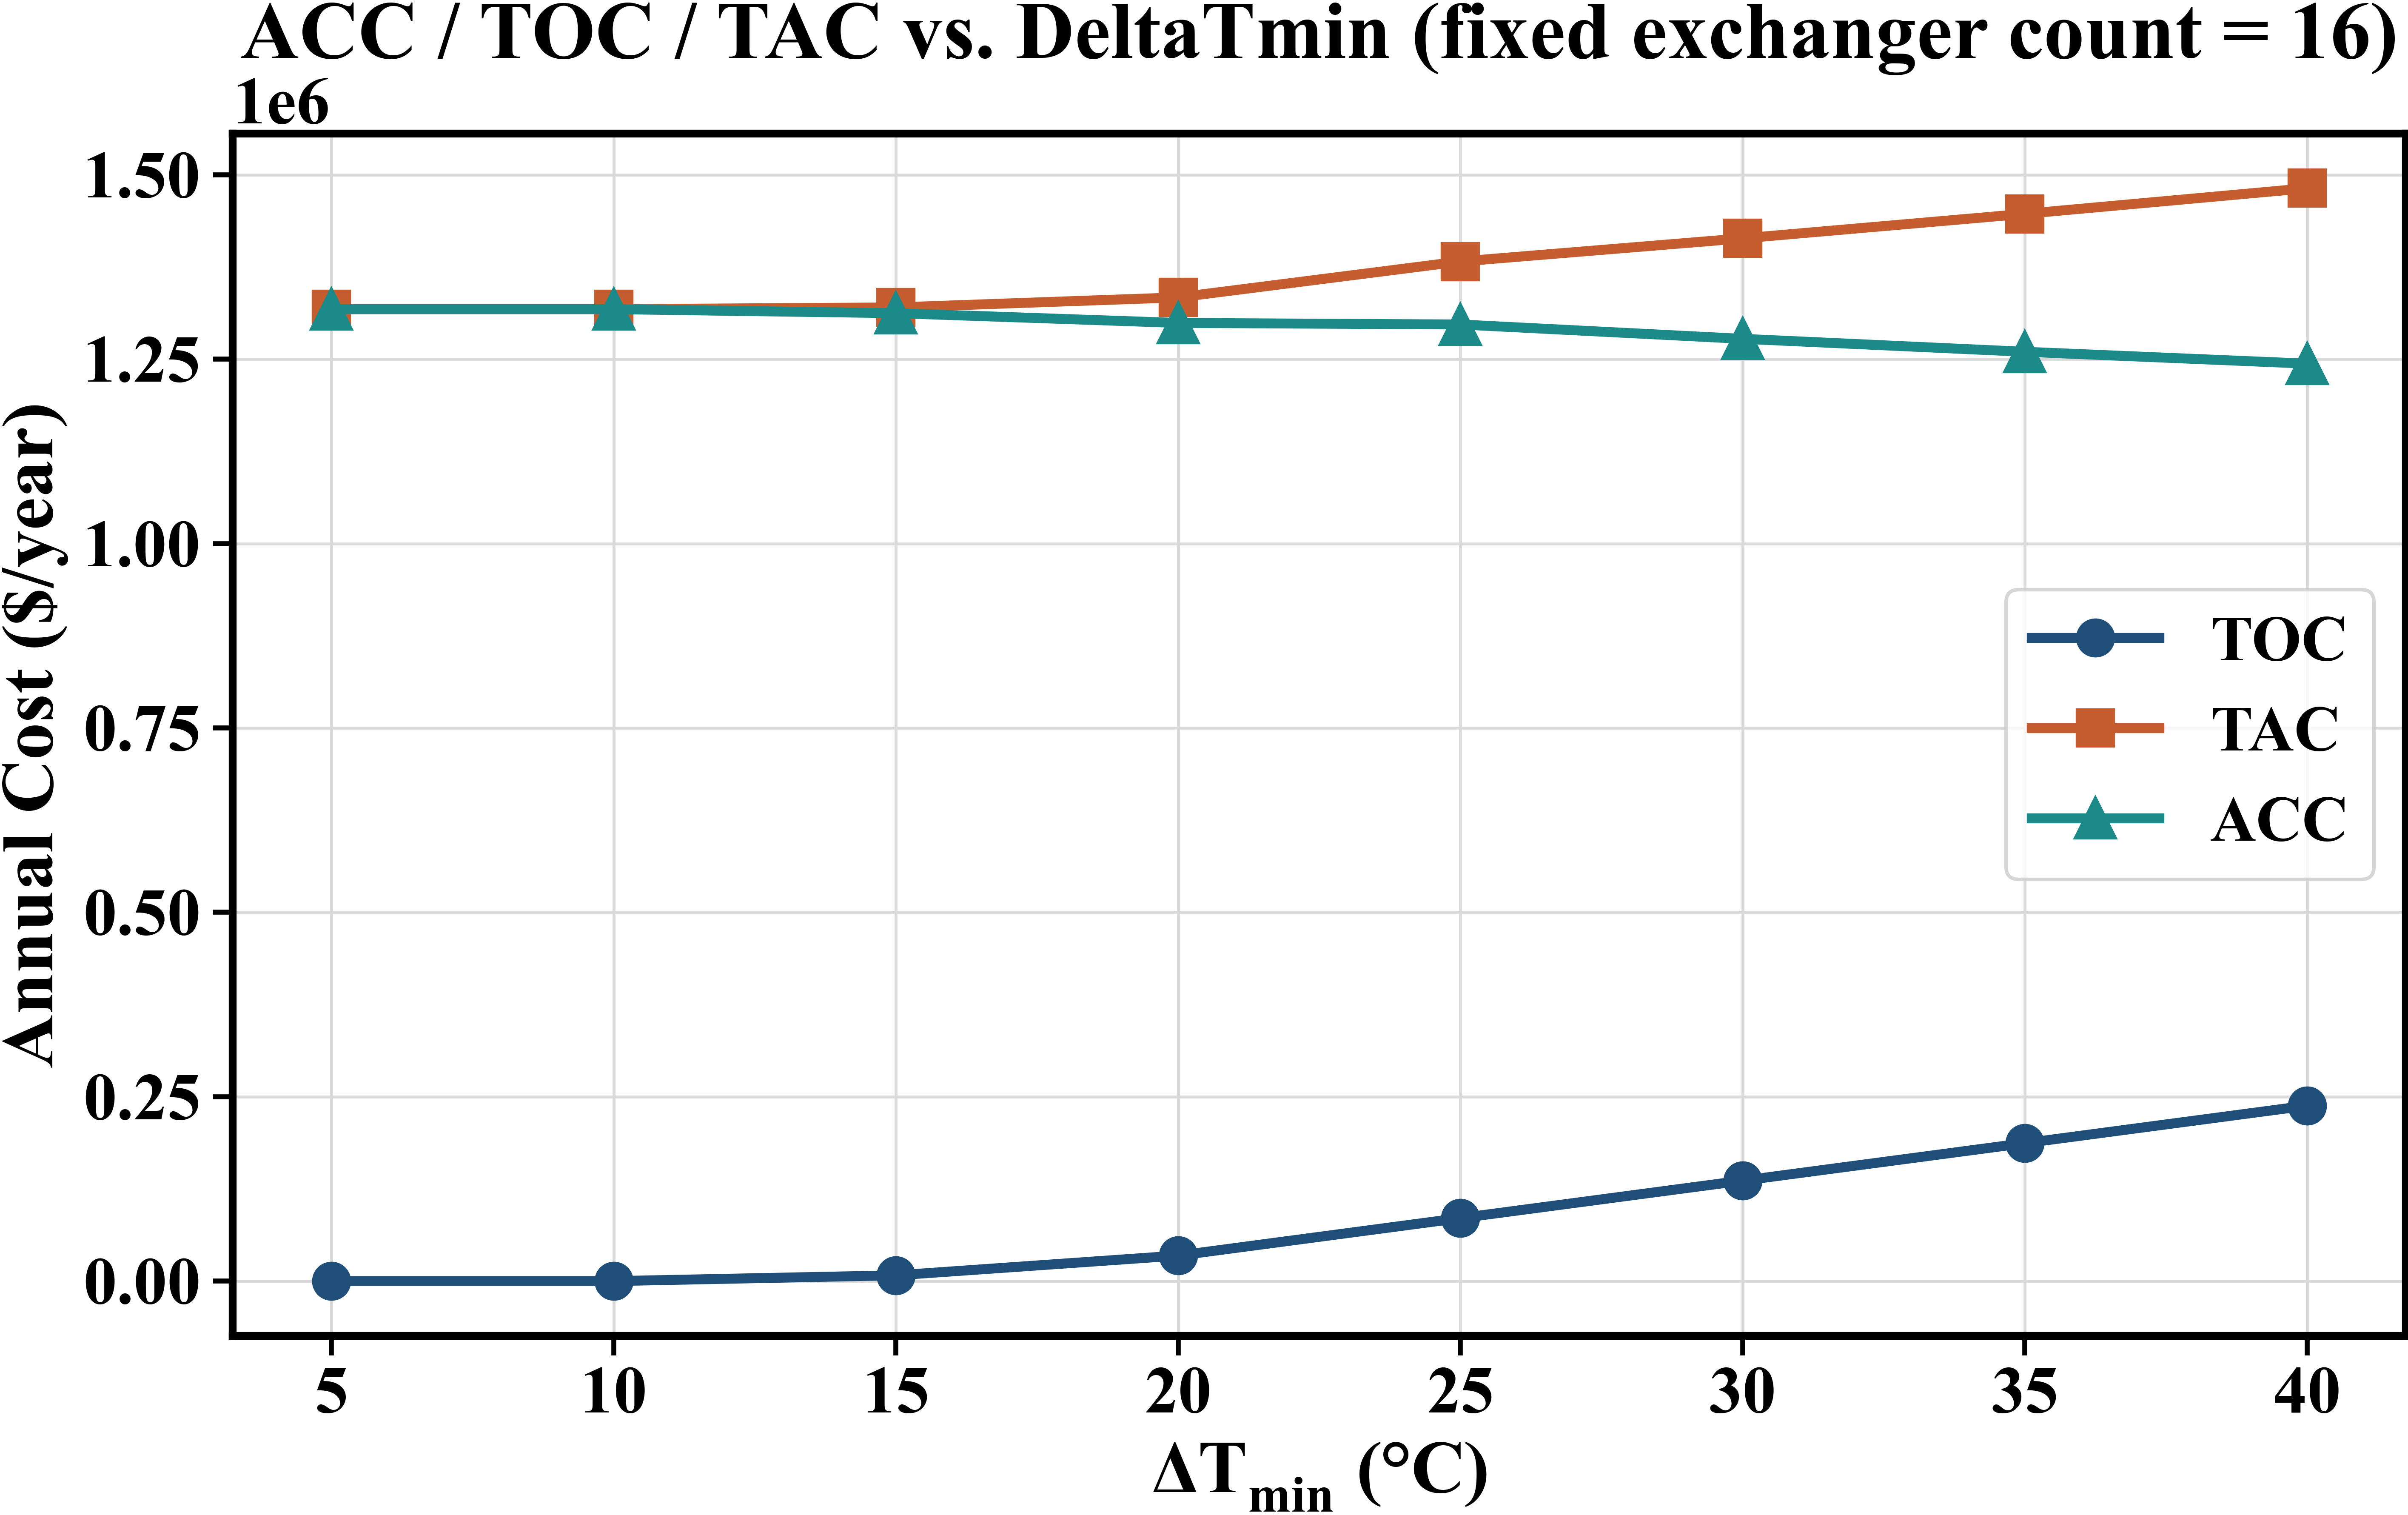

In [10]:
for title, path in figure_map.items():
    print(title)
    display(Image(filename=str(path)))


## Notes

- The demo uses the local copy of `Input Sheet of 20.xlsx` in this folder.
- Change `DELTA_TMIN_C` and rerun the notebook cells to test another case.
- The same backend can be reused later for publishing a cleaner standalone GitHub example.
- The `images/` subfolder is intended to keep the demo notebook self-contained.

## Acknowledgement

The authors also gratefully acknowledge A/Prof. Sachin V. Jangam for providing the HDA Aspen HYSYS case study through the course `CN4205R`, and for his teaching in `CN4205 Pinch Analysis and Process Integration`, from which this work benefited.

## Contact

Questions, feedback, or collaboration ideas are welcome. Please contact: `ziyun_zhang@u.nus.edu`